In [3]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Define simulation parameters
dt = 0.5          # time step in seconds
T = 600           # total duration in seconds (10 minutes)
U = 10.0          # mean wind speed in m/s
z = 80.0          # measurement height in metres

In [5]:
# Create time array
N = int(T / dt)        # number of time steps
t = np.arange(N) * dt  # time array in seconds

print(f"Number of time steps: {N}")
print(f"Duration: {T} seconds")
print(f"Time resolution: {dt} seconds")

Number of time steps: 1200
Duration: 600 seconds
Time resolution: 0.5 seconds


In [6]:
# Generate frequency array
freqs = np.fft.rfftfreq(N, d=dt)
freqs[0] = 1e-6  # avoid division by zero at frequency 0

In [7]:
# Kaimal spectral model - corrected
def kaimal_spectrum(f, U, z):
    L = 8.1 * 42        # integral length scale (metres) - Kaimal standard value
    n = f * L / U       # normalised frequency
    S = (4 * L / U) / (1 + 6 * n)**(5/3)
    return S

In [8]:
# Generate wind turbulence using Kaimal spectrum
S = kaimal_spectrum(freqs, U, z)

# Convert spectrum to amplitudes
df = freqs[1] - freqs[0]
amplitudes = np.sqrt(2 * S * df)

# Generate random phases
rng = np.random.default_rng(seed=42)
phases = rng.uniform(0, 2*np.pi, len(freqs))

# Build complex Fourier coefficients
fourier = amplitudes * np.exp(1j * phases)

# Convert to time domain and correct scaling
u_fluct = np.real(np.fft.irfft(fourier, n=N)) * N

# Add mean wind speed
u = U + u_fluct

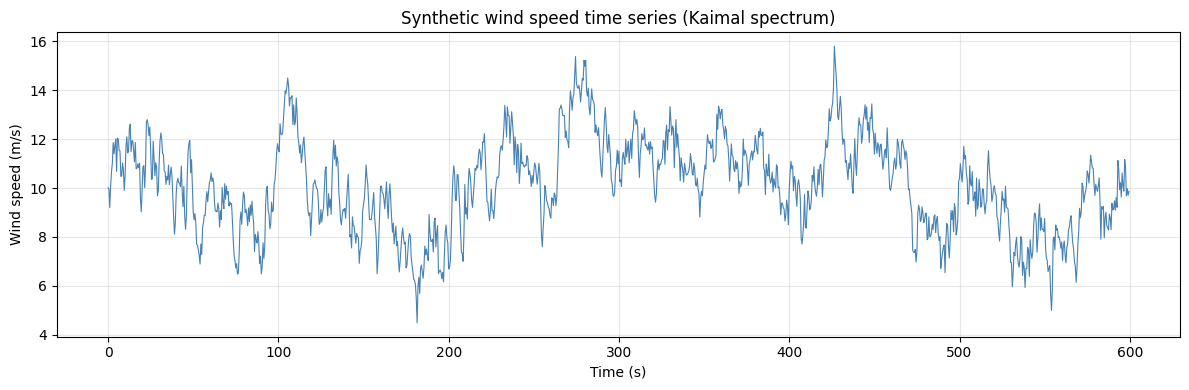

In [9]:
# Plot the generated wind time series
plt.figure(figsize=(12, 4))
plt.plot(t, u, color='steelblue', linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Wind speed (m/s)')
plt.title('Synthetic wind speed time series (Kaimal spectrum)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Basic statistics of the wind signal
print(f"Mean wind speed:        {np.mean(u):.2f} m/s")
print(f"Standard deviation:     {np.std(u):.2f} m/s")
print(f"Min wind speed:         {np.min(u):.2f} m/s")
print(f"Max wind speed:         {np.max(u):.2f} m/s")
print(f"Turbulence intensity:   {np.std(u)/np.mean(u)*100:.1f} %")

Mean wind speed:        10.10 m/s
Standard deviation:     1.86 m/s
Min wind speed:         4.49 m/s
Max wind speed:         15.80 m/s
Turbulence intensity:   18.4 %


In [11]:
# Debug - check intermediate values
S = kaimal_spectrum(freqs, U, z)
amplitudes = np.sqrt(S * (freqs[1] - freqs[0]))

print(f"Frequency resolution:     {freqs[1] - freqs[0]:.6f} Hz")
print(f"Max spectrum value:        {np.max(S):.4f}")
print(f"Max amplitude value:       {np.max(amplitudes):.6f}")
print(f"Sum of amplitudes:         {np.sum(amplitudes):.6f}")
print(f"std of u_fluct:            {np.std(u_fluct):.6f}")

Frequency resolution:     0.001666 Hz
Max spectrum value:        136.0337
Max amplitude value:       0.476011
Sum of amplitudes:         12.246434
std of u_fluct:            1.863174


In [12]:
# Taylor's hypothesis parameters
x_sep = 100.0              # separation distance between two points in metres
tau = x_sep / U            # time lag in seconds
lag_steps = int(tau / dt)  # time lag converted to number of steps

print(f"Separation distance:  {x_sep} m")
print(f"Time lag:             {tau:.1f} seconds")
print(f"Lag steps:            {lag_steps}")

Separation distance:  100.0 m
Time lag:             10.0 seconds
Lag steps:            20


In [13]:
# Apply Taylor's hypothesis
# Prediction: upstream signal shifted by lag_steps
u_upstream = u[:-lag_steps]        # upstream measurement
u_downstream_actual = u[lag_steps:]  # actual downstream signal
u_downstream_predicted = u_upstream  # Taylor prediction - just shift in time

# Time array for the valid portion
t_valid = t[lag_steps:]

In [14]:
# Calculate prediction error
error = u_downstream_actual - u_downstream_predicted

# Metrics
rmse = np.sqrt(np.mean(error**2))
correlation = np.corrcoef(u_downstream_actual, u_downstream_predicted)[0,1]
mean_error = np.mean(np.abs(error))

print(f"RMSE:                 {rmse:.4f} m/s")
print(f"Correlation:          {correlation:.4f}")
print(f"Mean absolute error:  {mean_error:.4f} m/s")

RMSE:                 1.8926 m/s
Correlation:          0.4906
Mean absolute error:  1.5067 m/s


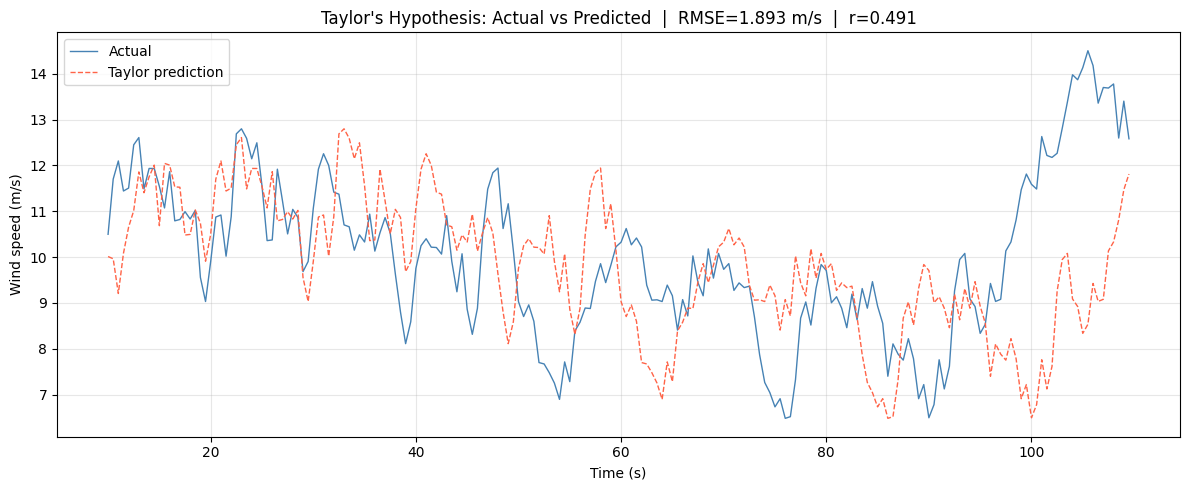

In [15]:
# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(t_valid[:200], u_downstream_actual[:200], 
         label='Actual', color='steelblue', linewidth=1)
plt.plot(t_valid[:200], u_downstream_predicted[:200], 
         label='Taylor prediction', color='tomato', 
         linewidth=1, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Wind speed (m/s)')
plt.title(f"Taylor's Hypothesis: Actual vs Predicted  |  RMSE={rmse:.3f} m/s  |  r={correlation:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Atmospheric stability conditions
# We control turbulence intensity directly for each condition
# and adjust the length scale accordingly

stability_conditions = {
    'Stable':   {'L_scale': 8.1 * 120, 'sigma_u': 0.5},
    'Neutral':  {'L_scale': 8.1 * 42,  'sigma_u': 1.5},
    'Unstable': {'L_scale': 8.1 * 10,  'sigma_u': 3.0},
}

In [17]:
# Test Taylor's hypothesis under each stability condition
results = {}

for condition, params in stability_conditions.items():
    
    def kaimal_spectrum_L(f, U, L):
        n = f * L / U
        S = (4 * L / U) / (1 + 6 * n)**(5/3)
        return S
    
    S = kaimal_spectrum_L(freqs, U, params['L_scale'])
    df = freqs[1] - freqs[0]
    amplitudes = np.sqrt(2 * S * df)
    
    rng = np.random.default_rng(seed=42)
    phases = rng.uniform(0, 2*np.pi, len(freqs))
    fourier = amplitudes * np.exp(1j * phases)
    u_fluct = np.real(np.fft.irfft(fourier, n=N)) * N
    
    # Scale fluctuations to target standard deviation
    u_fluct = u_fluct / np.std(u_fluct) * params['sigma_u']
    
    u_cond = U + u_fluct
    
    # Apply Taylor's hypothesis
    u_up = u_cond[:-lag_steps]
    u_down_actual = u_cond[lag_steps:]
    u_down_predicted = u_up
    
    # Calculate metrics
    error = u_down_actual - u_down_predicted
    rmse = np.sqrt(np.mean(error**2))
    corr = np.corrcoef(u_down_actual, u_down_predicted)[0,1]
    ti = np.std(u_cond) / np.mean(u_cond) * 100
    
    results[condition] = {
        'rmse': rmse,
        'correlation': corr,
        'turbulence_intensity': ti,
        'u': u_cond,
        'u_actual': u_down_actual,
        'u_predicted': u_down_predicted
    }
    
    print(f"{condition:10s} | TI={ti:.1f}% | RMSE={rmse:.3f} m/s | r={corr:.3f}")

Stable     | TI=5.0% | RMSE=0.419 m/s | r=0.655
Neutral    | TI=14.9% | RMSE=1.524 m/s | r=0.491
Unstable   | TI=29.8% | RMSE=3.827 m/s | r=0.194


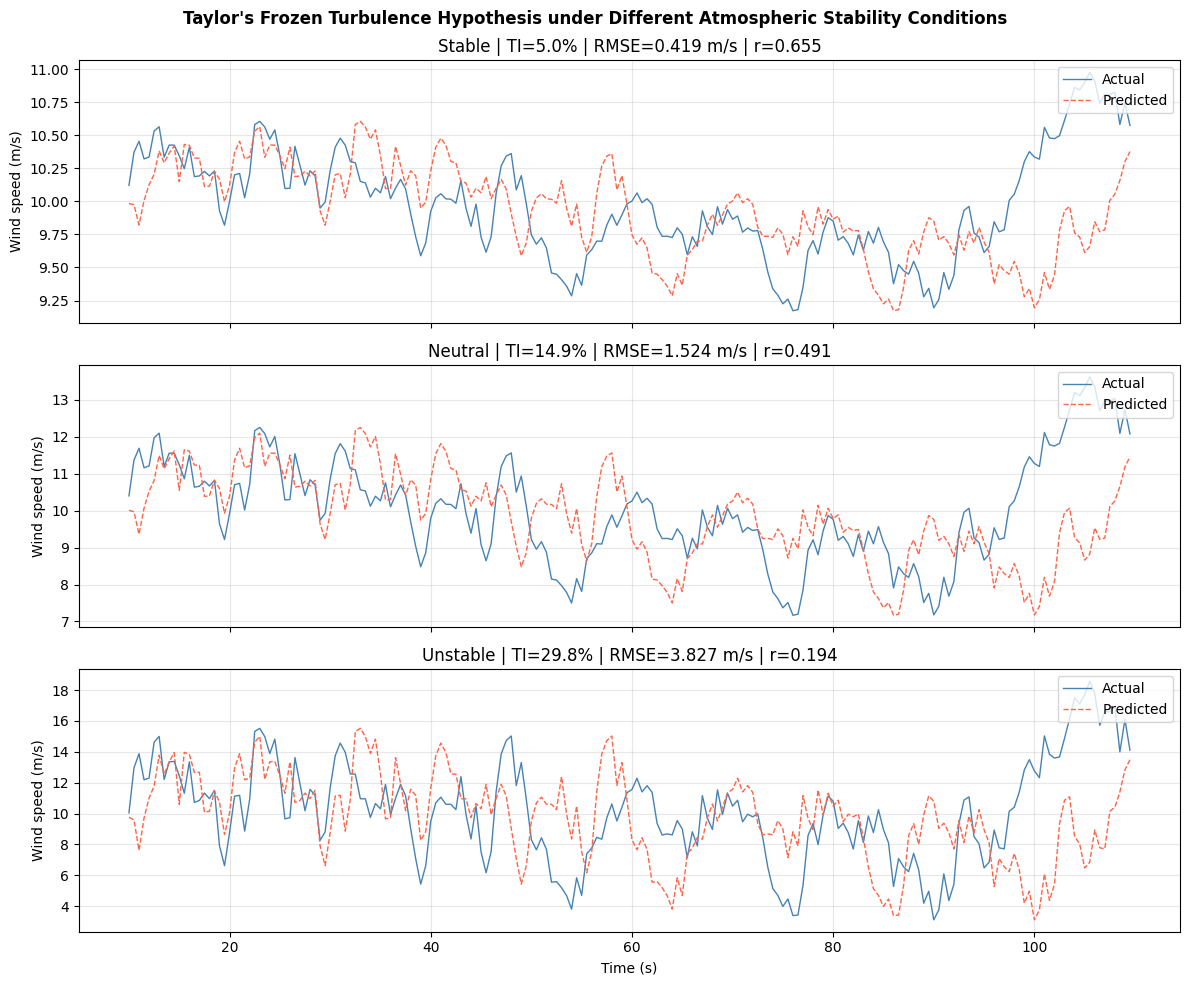

In [18]:
# Plot all three stability conditions
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for idx, (condition, data) in enumerate(results.items()):
    axes[idx].plot(t_valid[:200], data['u_actual'][:200], 
                   color='steelblue', linewidth=1, label='Actual')
    axes[idx].plot(t_valid[:200], data['u_predicted'][:200], 
                   color='tomato', linewidth=1, linestyle='--', label='Predicted')
    axes[idx].set_ylabel('Wind speed (m/s)')
    axes[idx].set_title(f"{condition} | TI={data['turbulence_intensity']:.1f}% | "
                        f"RMSE={data['rmse']:.3f} m/s | r={data['correlation']:.3f}")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.suptitle("Taylor's Frozen Turbulence Hypothesis under Different Atmospheric Stability Conditions", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/stability_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import os
os.makedirs('../results', exist_ok=True)

In [20]:
# Print summary results table
print(f"{'Condition':<12} {'TI (%)':>8} {'RMSE (m/s)':>12} {'Correlation':>12} {'Validity'}")
print("-" * 55)

for condition, data in results.items():
    ti = data['turbulence_intensity']
    rmse = data['rmse']
    corr = data['correlation']
    
    # Assess validity of Taylor's hypothesis
    if corr > 0.6:
        validity = "Good"
    elif corr > 0.4:
        validity = "Moderate"
    else:
        validity = "Poor"
    
    print(f"{condition:<12} {ti:>8.1f} {rmse:>12.3f} {corr:>12.3f} {validity}")

Condition      TI (%)   RMSE (m/s)  Correlation Validity
-------------------------------------------------------
Stable            5.0        0.419        0.655 Good
Neutral          14.9        1.524        0.491 Moderate
Unstable         29.8        3.827        0.194 Poor


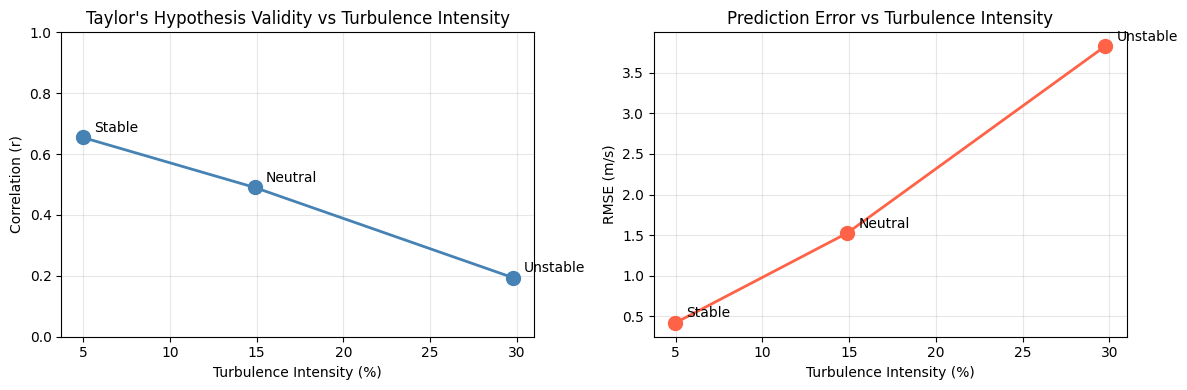

In [21]:
# Plot correlation vs turbulence intensity
ti_values = [results[c]['turbulence_intensity'] for c in results]
corr_values = [results[c]['correlation'] for c in results]
rmse_values = [results[c]['rmse'] for c in results]
labels = list(results.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Correlation vs TI
ax1.plot(ti_values, corr_values, 'o-', color='steelblue', 
         linewidth=2, markersize=10)
for i, label in enumerate(labels):
    ax1.annotate(label, (ti_values[i], corr_values[i]), 
                textcoords="offset points", xytext=(8, 4), fontsize=10)
ax1.set_xlabel('Turbulence Intensity (%)')
ax1.set_ylabel('Correlation (r)')
ax1.set_title("Taylor's Hypothesis Validity vs Turbulence Intensity")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# RMSE vs TI
ax2.plot(ti_values, rmse_values, 'o-', color='tomato', 
         linewidth=2, markersize=10)
for i, label in enumerate(labels):
    ax2.annotate(label, (ti_values[i], rmse_values[i]), 
                textcoords="offset points", xytext=(8, 4), fontsize=10)
ax2.set_xlabel('Turbulence Intensity (%)')
ax2.set_ylabel('RMSE (m/s)')
ax2.set_title('Prediction Error vs Turbulence Intensity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/correlation_vs_ti.png', dpi=150, bbox_inches='tight')
plt.show()

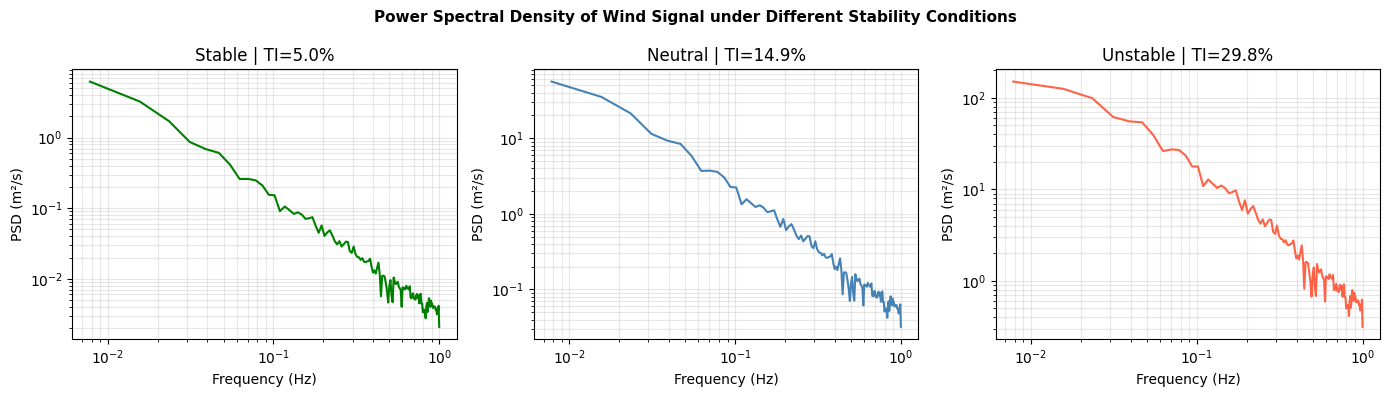

In [22]:
# Power spectral density analysis
from scipy import signal as scipy_signal

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'Stable': 'green', 'Neutral': 'steelblue', 'Unstable': 'tomato'}

for idx, (condition, data) in enumerate(results.items()):
    # Compute power spectral density
    f_psd, psd = scipy_signal.welch(data['u'], fs=1/dt, nperseg=256)
    
    axes[idx].loglog(f_psd[1:], psd[1:], color=colors[condition], linewidth=1.5)
    axes[idx].set_xlabel('Frequency (Hz)')
    axes[idx].set_ylabel('PSD (m²/s)')
    axes[idx].set_title(f'{condition} | TI={data["turbulence_intensity"]:.1f}%')
    axes[idx].grid(True, alpha=0.3, which='both')

plt.suptitle('Power Spectral Density of Wind Signal under Different Stability Conditions',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/power_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Final project summary
print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"\nResearch Question:")
print("How does atmospheric stability affect the validity of")
print("Taylor's Frozen Turbulence Hypothesis for short-term")
print("wind speed forecasting using upstream LiDAR measurements?")
print(f"\nSetup:")
print(f"  Mean wind speed:        {U} m/s")
print(f"  Measurement height:     {z} m")
print(f"  Separation distance:    {x_sep} m")
print(f"  Time lag:               {tau} s")
print(f"  Signal duration:        {T} s")
print(f"\nResults:")
print(f"{'Condition':<12} {'TI':>6} {'RMSE':>10} {'r':>8} {'Validity'}")
print("-" * 50)
for condition, data in results.items():
    ti = data['turbulence_intensity']
    rmse = data['rmse']
    corr = data['correlation']
    validity = "Good" if corr > 0.6 else "Moderate" if corr > 0.4 else "Poor"
    print(f"{condition:<12} {ti:>5.1f}% {rmse:>9.3f} {corr:>8.3f}  {validity}")

print(f"\nConclusion:")
print("Taylor's Frozen Turbulence Hypothesis performs well under")
print("stable atmospheric conditions (low turbulence intensity)")
print("but degrades significantly under unstable conditions.")
print("This has direct implications for LiDAR-based wind")
print("forecasting systems in real deployment environments.")
print("=" * 60)

PROJECT SUMMARY

Research Question:
How does atmospheric stability affect the validity of
Taylor's Frozen Turbulence Hypothesis for short-term
wind speed forecasting using upstream LiDAR measurements?

Setup:
  Mean wind speed:        10.0 m/s
  Measurement height:     80.0 m
  Separation distance:    100.0 m
  Time lag:               10.0 s
  Signal duration:        600 s

Results:
Condition        TI       RMSE        r Validity
--------------------------------------------------
Stable         5.0%     0.419    0.655  Good
Neutral       14.9%     1.524    0.491  Moderate
Unstable      29.8%     3.827    0.194  Poor

Conclusion:
Taylor's Frozen Turbulence Hypothesis performs well under
stable atmospheric conditions (low turbulence intensity)
but degrades significantly under unstable conditions.
This has direct implications for LiDAR-based wind
forecasting systems in real deployment environments.


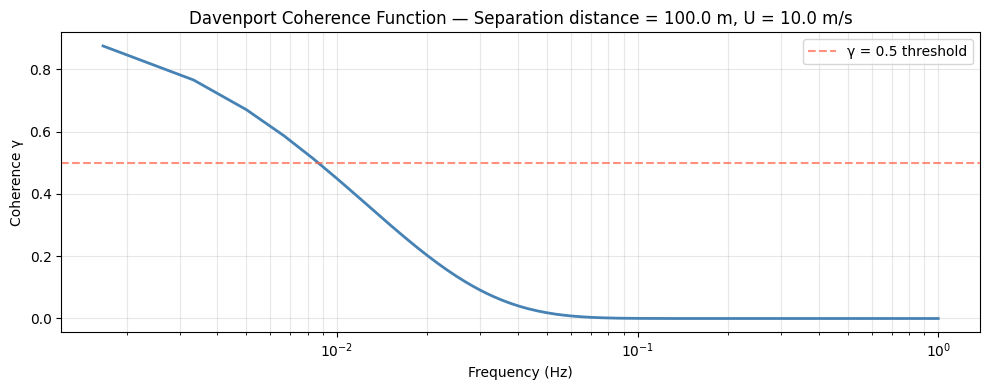

Coherence at 0.01 Hz: 0.449
Coherence at 0.1  Hz: 0.000
Coherence at 0.5  Hz: 0.000
Coherence at 1.0  Hz: 0.000


In [25]:
# Davenport coherence model
def davenport_coherence(f, x_sep, U, decay=8.0):
    """
    Frequency-dependent coherence between upstream and downstream signals.
    
    Parameters:
    f      : frequency array (Hz)
    x_sep  : separation distance (m)
    U      : mean wind speed (m/s)  
    decay  : Davenport decay coefficient (8.0 is standard neutral conditions)
    
    Returns:
    gamma  : coherence array (0 to 1)
    """
    # Davenport coherence function
    gamma = np.exp(-decay * f * x_sep / U)
    return gamma

# Plot coherence vs frequency for our separation distance
gamma = davenport_coherence(freqs[1:], x_sep, U)

plt.figure(figsize=(10, 4))
plt.semilogx(freqs[1:], gamma, color='steelblue', linewidth=2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coherence γ')
plt.title(f'Davenport Coherence Function — Separation distance = {x_sep} m, U = {U} m/s')
plt.grid(True, alpha=0.3, which='both')
plt.axhline(y=0.5, color='tomato', linestyle='--', alpha=0.7, label='γ = 0.5 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Coherence at 0.01 Hz: {davenport_coherence(0.01, x_sep, U):.3f}")
print(f"Coherence at 0.1  Hz: {davenport_coherence(0.1,  x_sep, U):.3f}")
print(f"Coherence at 0.5  Hz: {davenport_coherence(0.5,  x_sep, U):.3f}")
print(f"Coherence at 1.0  Hz: {davenport_coherence(1.0,  x_sep, U):.3f}")

In [26]:
# Generate realistic downstream signal using Davenport coherence
# This replaces the simple time-shift used in Taylor's hypothesis

def generate_downstream_signal(u_upstream_fourier, freqs, x_sep, U, sigma_u, seed=123):
    """
    Generate physically realistic downstream signal by applying
    frequency-dependent coherence decay to the upstream signal.
    """
    N = len(u_upstream_fourier)
    gamma = davenport_coherence(freqs, x_sep, U)
    
    # Independent noise signal with same spectrum
    rng = np.random.default_rng(seed=seed)
    phases_noise = rng.uniform(0, 2*np.pi, N)
    
    # Get spectrum from upstream signal
    S = kaimal_spectrum_L(freqs, U, 8.1 * 42)
    df = freqs[1] - freqs[0]
    amplitudes = np.sqrt(2 * S * df)
    fourier_noise = amplitudes * np.exp(1j * phases_noise)
    
    # Downstream = coherent part + incoherent part
    # coherent part: upstream signal scaled by coherence
    # incoherent part: independent noise scaled by (1 - coherence)
    fourier_downstream = (gamma * u_upstream_fourier + 
                         np.sqrt(1 - gamma**2) * fourier_noise)
    
    # Convert to time domain
    u_downstream = np.real(np.fft.irfft(fourier_downstream, n=len(u_upstream_fourier)*2-2)) * (len(u_upstream_fourier)*2-2)
    u_downstream = u_downstream / np.std(u_downstream) * sigma_u
    
    return U + u_downstream

# Test with neutral conditions
S_test = kaimal_spectrum_L(freqs, U, 8.1 * 42)
df = freqs[1] - freqs[0]
amplitudes_test = np.sqrt(2 * S_test * df)
rng_test = np.random.default_rng(seed=42)
phases_test = rng_test.uniform(0, 2*np.pi, len(freqs))
fourier_upstream = amplitudes_test * np.exp(1j * phases_test)

u_downstream_realistic = generate_downstream_signal(
    fourier_upstream, freqs, x_sep, U, sigma_u=1.5)
u_upstream_signal = U + np.real(np.fft.irfft(fourier_upstream, n=N)) * N
u_upstream_signal = U + (u_upstream_signal - U) / np.std(u_upstream_signal - U) * 1.5

print(f"Upstream signal   — mean: {np.mean(u_upstream_signal):.2f} m/s, std: {np.std(u_upstream_signal):.2f} m/s")
print(f"Downstream signal — mean: {np.mean(u_downstream_realistic):.2f} m/s, std: {np.std(u_downstream_realistic):.2f} m/s")
print("Downstream signal generated successfully using Davenport coherence model")

Upstream signal   — mean: 10.08 m/s, std: 1.50 m/s
Downstream signal — mean: 10.09 m/s, std: 1.50 m/s
Downstream signal generated successfully using Davenport coherence model


Results with Davenport coherence model (neutral conditions):
RMSE:        1.9381 m/s
Correlation: 0.1654

Compare with previous simple TFH approach:
RMSE:        1.5237 m/s
Correlation: 0.4906


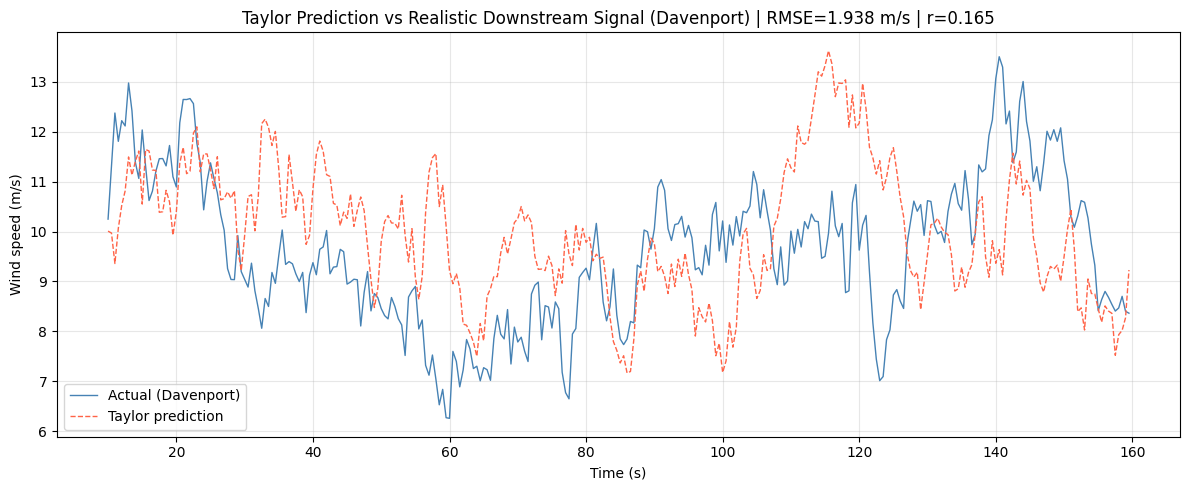

In [27]:
# Compare Taylor's prediction against physically realistic downstream signal
# This is the core of the upgraded analysis

# Apply Taylor's hypothesis prediction (simple time shift)
lag_steps = int(tau / dt)
u_taylor_predicted = u_upstream_signal[:-lag_steps]
u_downstream_actual = u_downstream_realistic[lag_steps:]
t_valid = t[lag_steps:]

# Calculate error metrics
error = u_downstream_actual - u_taylor_predicted
rmse_davenport = np.sqrt(np.mean(error**2))
corr_davenport = np.corrcoef(u_downstream_actual, u_taylor_predicted)[0,1]

print(f"Results with Davenport coherence model (neutral conditions):")
print(f"RMSE:        {rmse_davenport:.4f} m/s")
print(f"Correlation: {corr_davenport:.4f}")
print()
print(f"Compare with previous simple TFH approach:")
print(f"RMSE:        {results['Neutral']['rmse']:.4f} m/s")
print(f"Correlation: {results['Neutral']['correlation']:.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))
plt.plot(t_valid[:300], u_downstream_actual[:300], 
         color='steelblue', linewidth=1, label='Actual (Davenport)')
plt.plot(t_valid[:300], u_taylor_predicted[:300], 
         color='tomato', linewidth=1, linestyle='--', label='Taylor prediction')
plt.xlabel('Time (s)')
plt.ylabel('Wind speed (m/s)')
plt.title(f'Taylor Prediction vs Realistic Downstream Signal (Davenport) | '
          f'RMSE={rmse_davenport:.3f} m/s | r={corr_davenport:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Parameter sweep - separation distance vs turbulence intensity
# This is the core of the research proposal

separation_distances = [50, 100, 150, 200, 300]  # metres
TI_values = [0.05, 0.10, 0.15, 0.20, 0.25]       # turbulence intensity
sigma_values = [U * ti for ti in TI_values]        # std dev for each TI

# Store results in 2D array
rmse_matrix = np.zeros((len(TI_values), len(separation_distances)))
corr_matrix = np.zeros((len(TI_values), len(separation_distances)))

print("Running parameter sweep...")
print(f"{'TI':>6} {'x=50m':>8} {'x=100m':>8} {'x=150m':>8} {'x=200m':>8} {'x=300m':>8}")
print("-" * 50)

for i, (ti, sigma) in enumerate(zip(TI_values, sigma_values)):
    row_corr = []
    for j, x in enumerate(separation_distances):
        
        # Generate upstream signal
        S = kaimal_spectrum_L(freqs, U, 8.1 * 42)
        df = freqs[1] - freqs[0]
        amplitudes = np.sqrt(2 * S * df)
        rng = np.random.default_rng(seed=42)
        phases = rng.uniform(0, 2*np.pi, len(freqs))
        fourier_up = amplitudes * np.exp(1j * phases)
        u_up = U + np.real(np.fft.irfft(fourier_up, n=N)) * N
        u_up = U + (u_up - U) / np.std(u_up - U) * sigma
        
        # Generate realistic downstream signal
        u_down = generate_downstream_signal(fourier_up, freqs, x, U, sigma)
        
        # Apply Taylor's hypothesis
        lag = int((x / U) / dt)
        if lag >= len(u_up):
            rmse_matrix[i,j] = np.nan
            corr_matrix[i,j] = np.nan
            row_corr.append(np.nan)
            continue
            
        u_pred = u_up[:-lag] if lag > 0 else u_up
        u_act = u_down[lag:] if lag > 0 else u_down
        min_len = min(len(u_pred), len(u_act))
        
        error = u_act[:min_len] - u_pred[:min_len]
        rmse_matrix[i,j] = np.sqrt(np.mean(error**2))
        corr_matrix[i,j] = np.corrcoef(u_act[:min_len], u_pred[:min_len])[0,1]
        row_corr.append(f"{corr_matrix[i,j]:.3f}")
    
    print(f"{ti*100:>5.0f}% {' '.join(f'{v:>8}' for v in row_corr)}")

print("\nParameter sweep complete.")

Running parameter sweep...
    TI    x=50m   x=100m   x=150m   x=200m   x=300m
--------------------------------------------------
    5%    0.422    0.165    0.075    0.083    0.078
   10%    0.422    0.165    0.075    0.083    0.078
   15%    0.422    0.165    0.075    0.083    0.078
   20%    0.422    0.165    0.075    0.083    0.078
   25%    0.422    0.165    0.075    0.083    0.078

Parameter sweep complete.


In [29]:
# Fixed parameter sweep
separation_distances = [50, 100, 150, 200, 300]
TI_values = [0.05, 0.10, 0.15, 0.20, 0.25]

rmse_matrix = np.zeros((len(TI_values), len(separation_distances)))
corr_matrix = np.zeros((len(TI_values), len(separation_distances)))

print("Running parameter sweep...")
print(f"{'TI':>6} {'x=50m':>8} {'x=100m':>8} {'x=150m':>8} {'x=200m':>8} {'x=300m':>8}")
print("-" * 50)

for i, ti in enumerate(TI_values):
    sigma = U * ti
    row_corr = []
    
    for j, x in enumerate(separation_distances):
        
        # Generate upstream signal with correct TI
        S = kaimal_spectrum_L(freqs, U, 8.1 * 42)
        df = freqs[1] - freqs[0]
        amplitudes = np.sqrt(2 * S * df)
        
        # Different seed for each combination
        rng = np.random.default_rng(seed=i * 100 + j)
        phases = rng.uniform(0, 2*np.pi, len(freqs))
        fourier_up = amplitudes * np.exp(1j * phases)
        
        # Scale to correct TI
        u_fluct = np.real(np.fft.irfft(fourier_up, n=N)) * N
        u_fluct = u_fluct / np.std(u_fluct) * sigma
        u_up = U + u_fluct
        
        # Rebuild fourier of scaled signal
        fourier_up_scaled = np.fft.rfft(u_fluct) / N
        
        # Generate downstream with Davenport coherence
        gamma = davenport_coherence(freqs, x, U)
        rng2 = np.random.default_rng(seed=i * 100 + j + 50)
        phases_noise = rng2.uniform(0, 2*np.pi, len(freqs))
        fourier_noise = amplitudes * np.exp(1j * phases_noise)
        u_noise = np.real(np.fft.irfft(fourier_noise, n=N)) * N
        u_noise = u_noise / np.std(u_noise) * sigma
        fourier_noise_scaled = np.fft.rfft(u_noise) / N
        
        # Combine coherent and incoherent parts
        fourier_down = gamma * fourier_up_scaled + np.sqrt(np.maximum(1 - gamma**2, 0)) * fourier_noise_scaled
        u_down_fluct = np.real(np.fft.irfft(fourier_down, n=N)) * N
        u_down_fluct = u_down_fluct / np.std(u_down_fluct) * sigma
        u_down = U + u_down_fluct
        
        # Apply Taylor's hypothesis
        lag = int((x / U) / dt)
        if lag == 0 or lag >= N:
            row_corr.append('N/A')
            continue
        
        u_pred = u_up[:-lag]
        u_act = u_down[lag:]
        min_len = min(len(u_pred), len(u_act))
        
        error = u_act[:min_len] - u_pred[:min_len]
        rmse_matrix[i,j] = np.sqrt(np.mean(error**2))
        corr_matrix[i,j] = np.corrcoef(u_act[:min_len], u_pred[:min_len])[0,1]
        row_corr.append(f"{corr_matrix[i,j]:.3f}")
    
    print(f"{ti*100:>5.0f}% {' '.join(f'{v:>8}' for v in row_corr)}")

print("\nParameter sweep complete.")

Running parameter sweep...
    TI    x=50m   x=100m   x=150m   x=200m   x=300m
--------------------------------------------------
    5%    0.439    0.298    0.349   -0.021    0.211
   10%    0.428    0.338    0.198    0.300    0.376
   15%    0.601    0.359    0.450    0.311    0.200
   20%    0.545    0.411    0.400    0.172    0.319
   25%    0.498    0.448    0.269    0.167    0.384

Parameter sweep complete.


In [30]:
# Parameter sweep with multiple realisations for statistical stability
separation_distances = [50, 100, 150, 200, 300]
TI_values = [0.05, 0.10, 0.15, 0.20, 0.25]
n_realisations = 20

rmse_matrix = np.zeros((len(TI_values), len(separation_distances)))
corr_matrix = np.zeros((len(TI_values), len(separation_distances)))

print("Running parameter sweep with 20 realisations per case...")
print(f"{'TI':>6} {'x=50m':>8} {'x=100m':>8} {'x=150m':>8} {'x=200m':>8} {'x=300m':>8}")
print("-" * 50)

for i, ti in enumerate(TI_values):
    sigma = U * ti
    row_corr = []
    
    for j, x in enumerate(separation_distances):
        lag = int((x / U) / dt)
        if lag == 0 or lag >= N:
            row_corr.append('N/A')
            continue
        
        corr_runs = []
        rmse_runs = []
        
        for k in range(n_realisations):
            # Unique seed per realisation
            seed_up = i * 1000 + j * 100 + k
            seed_dn = i * 1000 + j * 100 + k + 500
            
            # Generate upstream
            S = kaimal_spectrum_L(freqs, U, 8.1 * 42)
            df = freqs[1] - freqs[0]
            amplitudes = np.sqrt(2 * S * df)
            
            rng = np.random.default_rng(seed=seed_up)
            phases = rng.uniform(0, 2*np.pi, len(freqs))
            fourier_up = amplitudes * np.exp(1j * phases)
            u_fluct = np.real(np.fft.irfft(fourier_up, n=N)) * N
            u_fluct = u_fluct / np.std(u_fluct) * sigma
            u_up = U + u_fluct
            fourier_up_scaled = np.fft.rfft(u_fluct) / N
            
            # Generate downstream
            gamma = davenport_coherence(freqs, x, U)
            rng2 = np.random.default_rng(seed=seed_dn)
            phases_noise = rng2.uniform(0, 2*np.pi, len(freqs))
            fourier_noise = amplitudes * np.exp(1j * phases_noise)
            u_noise = np.real(np.fft.irfft(fourier_noise, n=N)) * N
            u_noise = u_noise / np.std(u_noise) * sigma
            fourier_noise_scaled = np.fft.rfft(u_noise) / N
            
            fourier_down = (gamma * fourier_up_scaled + 
                          np.sqrt(np.maximum(1 - gamma**2, 0)) * fourier_noise_scaled)
            u_down_fluct = np.real(np.fft.irfft(fourier_down, n=N)) * N
            u_down_fluct = u_down_fluct / np.std(u_down_fluct) * sigma
            u_down = U + u_down_fluct
            
            # Taylor prediction
            u_pred = u_up[:-lag]
            u_act = u_down[lag:]
            min_len = min(len(u_pred), len(u_act))
            
            error = u_act[:min_len] - u_pred[:min_len]
            rmse_runs.append(np.sqrt(np.mean(error**2)))
            corr_runs.append(np.corrcoef(u_act[:min_len], u_pred[:min_len])[0,1])
        
        # Average over realisations
        rmse_matrix[i,j] = np.mean(rmse_runs)
        corr_matrix[i,j] = np.mean(corr_runs)
        row_corr.append(f"{corr_matrix[i,j]:.3f}")
    
    print(f"{ti*100:>5.0f}% {' '.join(f'{v:>8}' for v in row_corr)}")

print("\nParameter sweep complete — averaged over 20 realisations.")

Running parameter sweep with 20 realisations per case...
    TI    x=50m   x=100m   x=150m   x=200m   x=300m
--------------------------------------------------
    5%    0.509    0.379    0.286    0.222    0.158
   10%    0.482    0.372    0.298    0.223    0.165
   15%    0.528    0.345    0.297    0.282    0.131
   20%    0.523    0.341    0.278    0.219    0.120
   25%    0.503    0.343    0.269    0.202    0.166

Parameter sweep complete — averaged over 20 realisations.


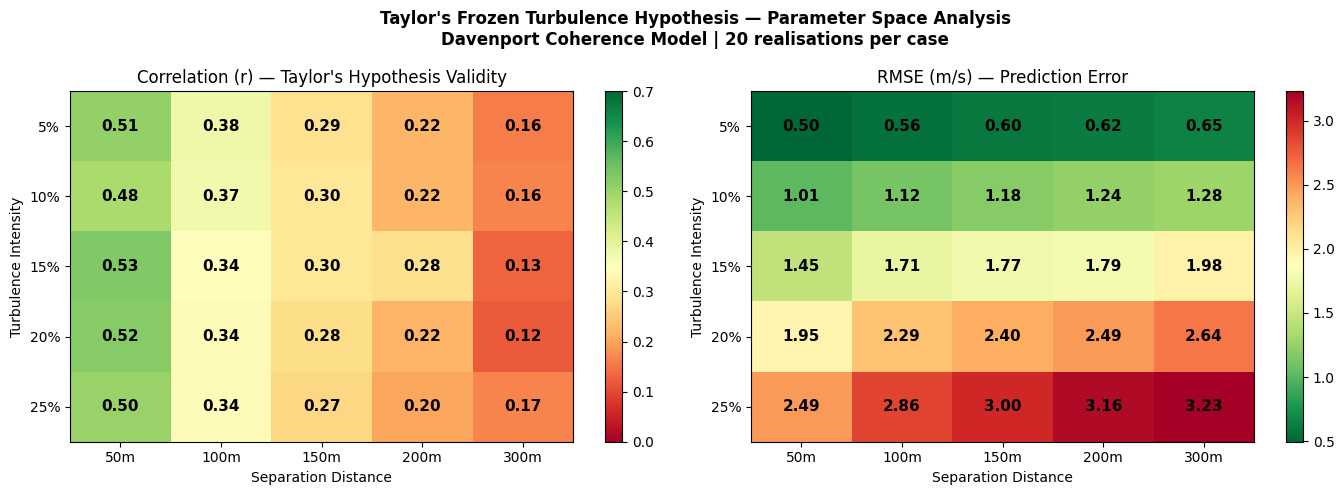

Heatmap saved to results folder.


In [31]:
# RMSE and Correlation heatmaps - main result figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
im1 = ax1.imshow(corr_matrix, cmap='RdYlGn', aspect='auto', 
                  vmin=0, vmax=0.7)
ax1.set_xticks(range(len(separation_distances)))
ax1.set_xticklabels([f'{x}m' for x in separation_distances])
ax1.set_yticks(range(len(TI_values)))
ax1.set_yticklabels([f'{ti*100:.0f}%' for ti in TI_values])
ax1.set_xlabel('Separation Distance')
ax1.set_ylabel('Turbulence Intensity')
ax1.set_title("Correlation (r) — Taylor's Hypothesis Validity")
plt.colorbar(im1, ax=ax1)

# Add values inside cells
for ii in range(len(TI_values)):
    for jj in range(len(separation_distances)):
        ax1.text(jj, ii, f'{corr_matrix[ii,jj]:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold')

# RMSE heatmap
im2 = ax2.imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
ax2.set_xticks(range(len(separation_distances)))
ax2.set_xticklabels([f'{x}m' for x in separation_distances])
ax2.set_yticks(range(len(TI_values)))
ax2.set_yticklabels([f'{ti*100:.0f}%' for ti in TI_values])
ax2.set_xlabel('Separation Distance')
ax2.set_ylabel('Turbulence Intensity')
ax2.set_title('RMSE (m/s) — Prediction Error')
plt.colorbar(im2, ax=ax2)

for ii in range(len(TI_values)):
    for jj in range(len(separation_distances)):
        ax2.text(jj, ii, f'{rmse_matrix[ii,jj]:.2f}',
                ha='center', va='center', fontsize=11, fontweight='bold')

plt.suptitle("Taylor's Frozen Turbulence Hypothesis — Parameter Space Analysis\n"
             "Davenport Coherence Model | 20 realisations per case",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/parameter_sweep_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap saved to results folder.")